# 04 — Preprocessing Benchmark, PCA, and Cluster Tendency

This notebook compares three preprocessing pipelines on the same 19,948 trajectory-level records. It demonstrates why preprocessing must be selected using both internal geometry and resampling stability.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TABLES = PROJECT_ROOT / "outputs" / "tables"
FIGURES = PROJECT_ROOT / "outputs" / "figures"

final_selection = pd.read_csv(TABLES / "stage4_preprocessing_selection_final.csv")
internal_benchmark = pd.read_csv(TABLES / "stage4_preprocessing_benchmark_summary.csv")
pca_variance = pd.read_csv(TABLES / "stage4_pca_explained_variance.csv")
hopkins = pd.read_csv(TABLES / "stage4_hopkins_summary.csv")
bootstrap = pd.read_csv(TABLES / "stage4_candidate_bootstrap_summary.csv")
city_predictability = pd.read_csv(TABLES / "stage4_city_predictability.csv")
config = json.loads((TABLES / "stage4_selected_preprocessing_config.json").read_text(encoding="utf-8"))

config

{'selected_pipeline': 'C_winsor_robust',
 'selected_preliminary_k': 2,
 'selection_basis': 'Internal metrics followed by mandatory bootstrap stability gate',
 'winsorize_continuous_features': True,
 'winsor_lower_quantile': 0.01,
 'winsor_upper_quantile': 0.99,
 'scaler': 'robust',
 'pca_variance_threshold': 0.9,
 'pca_components': 5,
 'pca_retained_variance': 0.9171415614610716,
 'bootstrap_ari_mean': 0.9819771347790199,
 'bootstrap_ari_min': 0.957289855433738,
 'bootstrap_unstable_repeats': 0,
 'preliminary_k_only': True,
 'rejected_internal_winner': 'B_raw_robust',
 'rejection_reason': 'Although B_raw_robust had the strongest preliminary silhouette and Hopkins scores, 2 of 20 bootstrap resamples collapsed, its minimum ARI fell to approximately 0.001, and the smallest predicted cluster fell to one trajectory. It therefore failed the mandatory stability gate.',
 'sensitivity_baseline': 'A_winsor_standard',
 'note': 'C_winsor_robust is the Stage 4 primary preprocessing baseline. The pr

## 1. Candidate pipelines

- **A:** 1st–99th percentile winsorization of eight continuous features, followed by StandardScaler.
- **B:** raw values followed by RobustScaler.
- **C:** winsorization followed by RobustScaler.

Stop-transition count and stopped-time ratio are preserved before scaling.

In [2]:
internal_benchmark[[
    "pipeline", "k", "pca_components", "pca_retained_variance",
    "silhouette", "davies_bouldin", "seed_stability_ari_mean",
    "hopkins_mean", "balanced_accuracy_mean"
]]

,pipeline,k,pca_components,pca_retained_variance,silhouette,davies_bouldin,seed_stability_ari_mean,hopkins_mean,balanced_accuracy_mean
0,B_raw_robust,2,5,0.900201,0.542717,0.971374,1.000000,0.992600,0.434347
1,C_winsor_robust,2,5,0.917142,0.489263,0.975464,0.998703,0.913009,0.433052
2,A_winsor_standard,3,5,0.903691,0.341384,1.186605,0.999246,0.940064,0.441437


## 2. PCA variance

PCA keeps the smallest number of components whose cumulative explained variance reaches at least 90%.

In [3]:
pca_variance

,pipeline,component,component_number,explained_variance_ratio,cumulative_explained_variance
0,A_winsor_standard,PC1,1,0.307616,0.307616
1,A_winsor_standard,PC2,2,0.290225,0.597841
2,A_winsor_standard,PC3,3,0.128370,0.726211
3,A_winsor_standard,PC4,4,0.124895,0.851107
4,A_winsor_standard,PC5,5,0.052584,0.903691
5,B_raw_robust,PC1,1,0.463242,0.463242
6,B_raw_robust,PC2,2,0.174393,0.637635
7,B_raw_robust,PC3,3,0.130644,0.768279
8,B_raw_robust,PC4,4,0.074317,0.842595
9,B_raw_robust,PC5,5,0.057606,0.900201


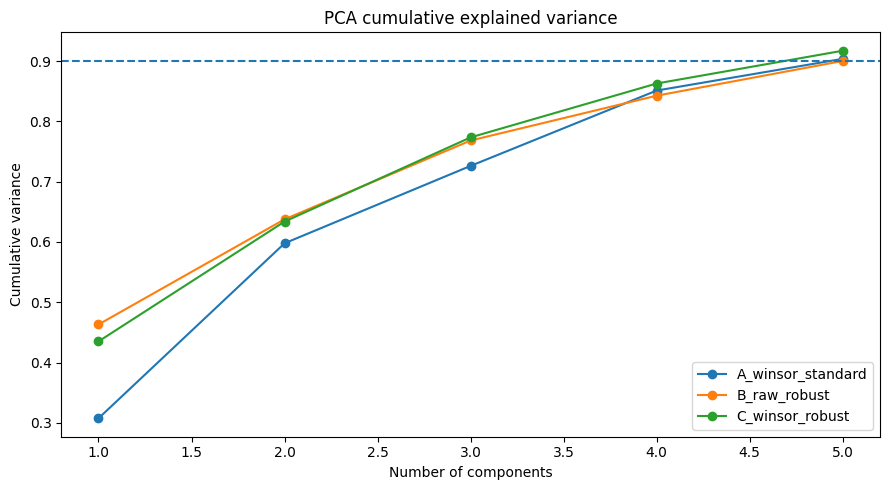

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for pipeline_name, group in pca_variance.groupby("pipeline"):
    ax.plot(
        group["component_number"],
        group["cumulative_explained_variance"],
        marker="o",
        label=pipeline_name,
    )
ax.axhline(0.90, linestyle="--")
ax.set_title("PCA cumulative explained variance")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative variance")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Hopkins statistic

Values substantially above 0.50 indicate departure from spatial randomness. Hopkins does not identify the correct algorithm and can be inflated by fragile extreme structures.

In [5]:
hopkins

,index,pipeline,hopkins_mean,hopkins_std,hopkins_min,hopkins_max
0,0,A_winsor_standard,0.940064,0.001134,0.938481,0.941722
1,1,B_raw_robust,0.992600,0.000800,0.990404,0.993042
2,2,C_winsor_robust,0.913009,0.002205,0.910274,0.916212


## 4. Bootstrap stability gate

Seed stability uses the same full dataset repeatedly. Bootstrap stability is stronger because each model is fitted on a resampled dataset and then compared with the full-data reference partition.

In [6]:
bootstrap

,pipeline,k,bootstrap_ari_mean,bootstrap_ari_median,bootstrap_ari_min,bootstrap_unstable_repeats,bootstrap_min_cluster_share_mean,bootstrap_min_cluster_share_min
0,A_winsor_standard,3,0.985963,0.988727,0.965713,0,0.153850,0.143623
1,B_raw_robust,2,0.880152,0.982746,0.000903,2,0.083683,0.000050
2,C_winsor_robust,2,0.981977,0.983622,0.957290,0,0.097927,0.092942


Pipeline B looked strongest from internal metrics but failed the bootstrap gate: two runs collapsed and the minimum ARI was approximately zero.

In [7]:
final_selection[[
    "pipeline", "k", "silhouette", "davies_bouldin",
    "bootstrap_ari_mean", "bootstrap_ari_min",
    "bootstrap_unstable_repeats", "bootstrap_min_cluster_share_min",
    "passes_bootstrap_stability_gate", "stability_gated_selection_score"
]]

,pipeline,k,silhouette,davies_bouldin,bootstrap_ari_mean,bootstrap_ari_min,bootstrap_unstable_repeats,bootstrap_min_cluster_share_min,passes_bootstrap_stability_gate,stability_gated_selection_score
0,C_winsor_robust,2,0.489263,0.975464,0.981977,0.957290,0,0.092942,True,0.700000
1,A_winsor_standard,3,0.341384,1.186605,0.985963,0.965713,0,0.143623,True,0.666667
2,B_raw_robust,2,0.542717,0.971374,0.880152,0.000903,2,0.000050,False,-1.000000


## 5. Final Stage 4 decision

`C_winsor_robust` is the primary preprocessing baseline. `A_winsor_standard` remains the sensitivity baseline.

The preliminary `k=2` result is not the final behavioral-profile decision. It only identifies the strongest broad split during preprocessing screening.

In [8]:
city_predictability

,pipeline,balanced_accuracy_mean,balanced_accuracy_std,chance_balanced_accuracy
0,A_winsor_standard,0.441437,0.006379,0.25
1,B_raw_robust,0.434347,0.003701,0.25
2,C_winsor_robust,0.433052,0.004704,0.25


Balanced city-prediction accuracy remains above the 0.25 chance level. City context therefore remains present and must be tested through cross-city validation.

## Conclusion

Selected Stage 4 pipeline:

```text
1st–99th percentile winsorization on eight continuous features
→ RobustScaler
→ PCA retaining at least 90% variance
→ five components, 91.71% retained variance
```

The next stage performs the full clustering-model benchmark and interprets candidate behavioral profiles.